Nom : Khadijetou Mohamed abe

Filière : GLCC

# 1.CODE SCRATCH

In [10]:
import numpy as np

def noyau_lineaire(x1, x2):
    # '''
    # Calcule le produit scalaire entre deux vecteurs x1 et x2.
    # Dans le cas du SVM, cela sert de fonction noyau linéaire.
    # '''
    return np.dot(x1, x2)


def predict_i(i, X, y, W, b):
    # """
    # Calcule la valeur de l'équation de l'hyperplan pour un point donné i.
    # f(x_i) = W . x_i + b
    # Si le résultat est > 0, le modèle penche pour la classe +1.
    # Si le résultat est < 0, le modèle penche pour la classe -1.
    # """
    return noyau_lineaire(W, X[i]) + b


def update_alphas(i, X, y, W, b, pas, lambda_param):
    # """
    # Mise à jour des poids W et du biais b pour un seul point.
    # """
    # On extrait les caractéristiques du point i et son label réel
    x_i = X[i]
    y_i = y[i]
    
    # On vérifie la condition de la marge : y_i * (W.x_i + b)
    condition = y_i * (noyau_lineaire(x_i, W) + b)
    
    if condition < 1:
        # Si la condition est < 1, le point est mal classé OU il est dans la marge.
        # On doit donc corriger W et b en appliquant le gradient de l'erreur + la régularisation.
        W = W + pas * (y_i * x_i - 2 * lambda_param * W)
        b = b + pas * y_i
    else:
        # Si la condition est >= 1, le point est bien classé et en dehors de la marge.
        # L'erreur est nulle, on applique SEULEMENT la régularisation sur W pour maximiser la marge.
        W = W + pas * (-2 * lambda_param * W)

    return True, W, b


def SVM(X, y, pas=0.01, lambda_param=0.01, k_max=100):
    # """
    # Fonction principale pour entraîner le modèle SVM from scratch.
    # On itère sur tous les points pour ajuster progressivement l'hyperplan.
    # """
    # Nombre total d'exemples dans notre dataset
    n = len(X)

    # Initialisation du vecteur de poids W à des zéros
    W = np.zeros(X.shape[1])
    # Initialisation du biais à 0
    b = 0
    
    # Compteur d'itérations
    k = 0
    
    # Boucle d'apprentissage
    while k <= k_max:
        # Pour chaque itération, on passe sur TOUS les points du dataset un par un 
        for i in range(n):
            _, W, b = update_alphas(i, X, y, W, b, pas, lambda_param)
        k += 1
    
    return W, b


def get_support_vectors(X, y, W, b, epsilon=10**-5):
    # """
    # Identifie les vecteurs de support. 
    # Ce sont les points qui sont exactement sur la marge (distance = 1) (à peu près égal à 1) 
    # """
    # On calcule la distance fonctionnelle de chaque point yi.(W . x_i + b) (produit de y avec (X.dot(W) + b) ligne par ligne)
    distances = y * (X.dot(W) + b)
    # np.where renvoie les indices des points dont la distance est proche de 1 ou inférieure
    return np.where(distances - 1 <= epsilon)[0]

## a. DATASET

In [5]:
# a. DATASET

np.random.seed(40)

# Classe -1 (en haut à gauche)
# Création de la Classe -1 (un nuage de points situé en haut à gauche)
# loc=[3, 7] : centre du nuage (x=3, y=7)
# scale=1.5 : dispersion des points
X_A = np.random.normal(loc=[3, 7], scale=1.5, size=(20, 2))
# On assigne le label -1 à ces 20 points
y_A = np.full((20,), -1) 

# Création de la Classe 1 (un nuage de points situé en bas à droite)
# loc=[7, 3] : centre du nuage (x=7, y=3)
X_B = np.random.normal(loc=[7, 3], scale=1.5, size=(20, 2))
# On assigne le label 1 à ces 20 points
y_B = np.full((20,), 1) 

# On assemble (fusionne) les deux nuages de points verticalement pour X et horizontalement pour Y
X_data_svm = np.vstack((X_A, X_B))
y_data_svm = np.hstack((y_A, y_B))

## b. Exécution du code scratch

In [11]:

# k_max=1200 pour itérations, je l'augmente afin d'assurer la convergence
W_scratch, b_scratch = SVM(X_data_svm, y_data_svm , k_max=1200)


## c. Code sklearn

In [12]:
# Import de la classe SVM (Support Vector Classification)
from sklearn.svm import SVC

# On crée le modèle sklearn avec un noyau linéaire 
# C=1 est le paramètre de régularisation (inverse de notre lambda_param)
modele_sklearn_svm = SVC(kernel='linear', C=1)

# On entraîne le modèle sur nos données
modele_sklearn_svm.fit(X_data_svm, y_data_svm)

# On extrait les poids W (coef_) et le biais b (intercept_) trouvés par sklearn
# np.squeeze enlève les dimensions inutiles du tableau renvoyé par sklearn
W_sklearn = np.squeeze(modele_sklearn_svm.coef_)
b_sklearn = modele_sklearn_svm.intercept_[0]

# Sklearn nous donne directement les indices des vecteurs de support via l'attribut .support_
vs_sklearn_idx = modele_sklearn_svm.support_

## d. Compasraison et graphiques (scratch/sklearn)

--- Comparaison des paramètres W et b ---
Scratch : W = [0.4429, -0.7719]] | b = 1.6800
Sklearn : W = [0.4152, -0.7542] | b = 1.7159
Support vectors scratch indices: [ 9 13 35 37]
Support vectors sklearn indices: [ 9 13 35]


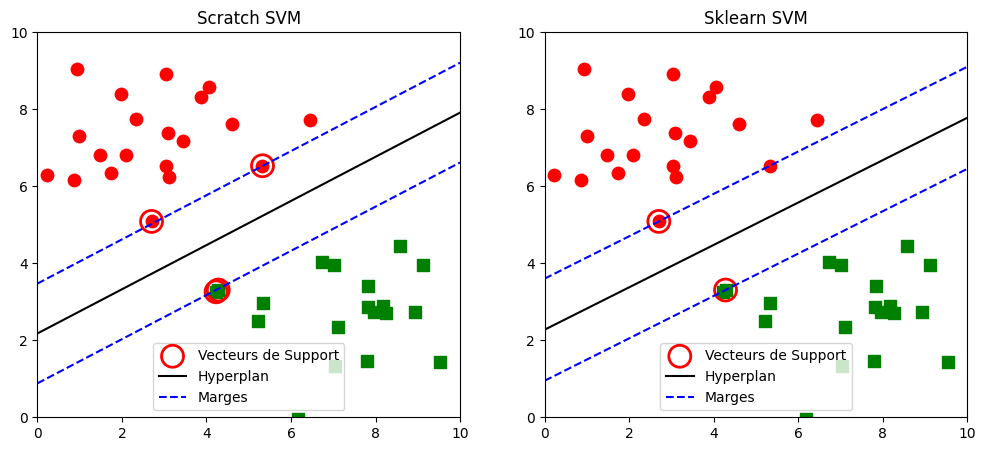

In [14]:
print("--- Comparaison des paramètres W et b ---")
print(f"Scratch : W = [{W_scratch[0]:.4f}, {W_scratch[1]:.4f}]] | b = {b_scratch:.4f}")
print(f"Sklearn : W = [{W_sklearn[0]:.4f}, {W_sklearn[1]:.4f}] | b = {b_sklearn:.4f}")


import matplotlib.pyplot as plt

# Fonction d'affichage pour éviter de répéter le code du graphique deux fois
def plot_svm(X, y, W, b, support_idx, ax):
    # """Trace les points, l'hyperplan, les marges et entoure les vecteurs de support"""
    
    # séparation des classes
    X_A = X[y == -1]
    X_B = X[y == 1]

    ax.scatter(X_A[:, 0], X_A[:, 1], color='r', marker='o', s=80)
    ax.scatter(X_B[:, 0], X_B[:, 1], color='g', marker='s', s=80)

    # entoure les vecteurs de support
    vecteurs_support = X[support_idx]
    ax.scatter(vecteurs_support[:, 0], vecteurs_support[:, 1],s=250,facecolors='none',edgecolors='red',linewidth=2,label='Vecteurs de Support')

    # hyperplan
    x_val = np.linspace(0, 10, 100)
    
    # condition pour éviter la division par zéro
    if W[1] != 0:
        # L'équation de base est : W0*x0 + W1*x1 + b = 0
        y_hyperplan = -(W[0] / W[1]) * x_val - (b / W[1])
        
        # Les marges sont à une distance de +1 et -1
        y_marge_1 = -(W[0] / W[1]) * x_val - ((b - 1) / W[1])
        y_marge_moins_1 = -(W[0] / W[1]) * x_val - ((b + 1) / W[1])

        ax.plot(x_val, y_hyperplan, color='black', linestyle='-', label='Hyperplan')
        ax.plot(x_val, y_marge_1, color='blue', linestyle='--', label='Marges')
        ax.plot(x_val, y_marge_moins_1, color='blue', linestyle='--')

    ax.set_title('SVM')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.legend()

# get support vectors
support_idx_scratch = get_support_vectors(X_data_svm, y_data_svm, W_scratch, b_scratch , 10**-1)
print("Support vectors scratch indices:", support_idx_scratch)
print("Support vectors sklearn indices:", vs_sklearn_idx)


# plot
plt.figure(figsize=(12, 5))

ax1 = plt.subplot(1, 2, 1)
plot_svm(X_data_svm, y_data_svm, W_scratch, b_scratch, support_idx_scratch, ax1)
ax1.set_title("Scratch SVM")

ax2 = plt.subplot(1, 2, 2)
plot_svm(X_data_svm, y_data_svm, W_sklearn, b_sklearn, support_idx_sklearn, ax2)
ax2.set_title("Sklearn SVM")

plt.show()